In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


In [5]:
!mkdir -p /content/data/raw

In [6]:
!unzip -q archive.zip -d /content/data/raw/

In [7]:
import os
files_list = os.listdir('/content/data/raw/')
print(f"Total files: {len(files_list)}")
print(files_list[:10])

Total files: 52
['ASIANPAINT.csv', 'RELIANCE.csv', 'BAJAJ-AUTO.csv', 'ZEEL.csv', 'LT.csv', 'TATAMOTORS.csv', 'SUNPHARMA.csv', 'TATASTEEL.csv', 'BPCL.csv', 'NIFTY50_all.csv']


In [9]:
!pip install plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded ✅")

All libraries loaded ✅


In [10]:
DATA_PATH = "/content/data/raw/"

# Load all stock CSVs (skip NIFTY50_all.csv for now)
all_files = [f for f in os.listdir(DATA_PATH)
             if f.endswith('.csv') and f != 'NIFTY50_all.csv']

dfs = []
for file in all_files:
    df = pd.read_csv(os.path.join(DATA_PATH, file))
    df['Symbol'] = file.replace('.csv', '')
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data['Date'] = pd.to_datetime(data['Date'])
data.sort_values(['Symbol', 'Date'], inplace=True)
data.reset_index(drop=True, inplace=True)

print(f"Total records : {len(data):,}")
print(f"Total stocks  : {data['Symbol'].nunique()}")
print(f"Date range    : {data['Date'].min().date()} to {data['Date'].max().date()}")
print(f"\nColumns: {data.columns.tolist()}")

Total records : 235,242
Total stocks  : 50
Date range    : 2000-01-03 to 2021-04-30

Columns: ['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble', 'Company Name', 'Industry', 'ISIN Code']


In [11]:
print("Shape:", data.shape)
print("\nMissing Values:")
print(data.isnull().sum())
print("\nSample Data:")
data.head()

Shape: (235242, 18)

Missing Values:
Date                      50
Symbol                     0
Series                     0
Prev Close                50
Open                      50
High                      50
Low                       50
Last                      50
Close                     50
VWAP                      50
Volume                    50
Turnover                  50
Trades                114898
Deliverable Volume     16127
%Deliverble            16127
Company Name          235192
Industry              235192
ISIN Code             235192
dtype: int64

Sample Data:


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Company Name,Industry,ISIN Code
0,2007-11-27,ADANIPORTS,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366.0,2.687719e+15,NaN,9859619.0,0.3612,NaN,NaN,NaN
1,2007-11-28,ADANIPORTS,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338.0,4.312765e+14,NaN,1453278.0,0.3172,NaN,NaN,NaN
2,2007-11-29,ADANIPORTS,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121.0,4.550658e+14,NaN,1069678.0,0.2088,NaN,NaN,NaN
3,2007-11-30,ADANIPORTS,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762.0,4.283257e+14,NaN,1260913.0,0.2735,NaN,NaN,NaN
4,2007-12-03,ADANIPORTS,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470.0,2.875200e+14,NaN,816123.0,0.2741,NaN,NaN,NaN


In [12]:
# Company Name, Industry, ISIN are mostly NaN - fill from NIFTY50_all.csv
meta = pd.read_csv("/content/data/raw/NIFTY50_all.csv")
print(meta.columns.tolist())
print(meta.head(3))

['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']
         Date      Symbol Series  Prev Close   Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ       440.0  770.0  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ       962.9  984.0   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ       893.9  909.0   914.75  841.0  887.0   

   Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.9  984.72  27294366  2.687719e+15     NaN           9859619.0   
1  893.9  941.38   4581338  4.312765e+14     NaN           1453278.0   
2  884.2  888.09   5124121  4.550658e+14     NaN           1069678.0   

   %Deliverble  
0       0.3612  
1       0.3172  
2       0.2088  


In [13]:
# Drop mostly empty metadata columns
data.drop(columns=['Company Name', 'Industry', 'ISIN Code'], inplace=True)

# Drop rows where price data is missing
data.dropna(subset=['Open', 'High', 'Low', 'Close'], inplace=True)

print("Missing values after cleaning:")
print(data.isnull().sum())
print(f"\nFinal shape: {data.shape}")

Missing values after cleaning:
Date                       0
Symbol                     0
Series                     0
Prev Close                 0
Open                       0
High                       0
Low                        0
Last                       0
Close                      0
VWAP                       0
Volume                     0
Turnover                   0
Trades                114848
Deliverable Volume     16077
%Deliverble            16077
dtype: int64

Final shape: (235192, 15)


In [14]:
sector_map = {
    'ADANIPORTS': 'Infrastructure', 'ASIANPAINT': 'Consumer Goods',
    'AXISBANK': 'Banking', 'BAJAJ-AUTO': 'Automobile',
    'BAJAJFINSV': 'Financial Services', 'BAJFINANCE': 'Financial Services',
    'BHARTIARTL': 'Telecom', 'BPCL': 'Energy',
    'BRITANNIA': 'Consumer Goods', 'CIPLA': 'Pharma',
    'COALINDIA': 'Energy', 'DRREDDY': 'Pharma',
    'EICHERMOT': 'Automobile', 'GAIL': 'Energy',
    'GRASIM': 'Cement', 'HCLTECH': 'IT',
    'HDFC': 'Financial Services', 'HDFCBANK': 'Banking',
    'HDFCLIFE': 'Insurance', 'HEROMOTOCO': 'Automobile',
    'HINDALCO': 'Metals', 'HINDUNILVR': 'Consumer Goods',
    'ICICIBANK': 'Banking', 'INDUSINDBK': 'Banking',
    'INFY': 'IT', 'IOC': 'Energy',
    'ITC': 'Consumer Goods', 'JSWSTEEL': 'Metals',
    'KOTAKBANK': 'Banking', 'LT': 'Infrastructure',
    'M&M': 'Automobile', 'MARUTI': 'Automobile',
    'NESTLEIND': 'Consumer Goods', 'NTPC': 'Energy',
    'ONGC': 'Energy', 'POWERGRID': 'Energy',
    'RELIANCE': 'Energy', 'SBILIFE': 'Insurance',
    'SBIN': 'Banking', 'SHREECEM': 'Cement',
    'SUNPHARMA': 'Pharma', 'TATACONSUM': 'Consumer Goods',
    'TATAMOTORS': 'Automobile', 'TATASTEEL': 'Metals',
    'TCS': 'IT', 'TECHM': 'IT',
    'TITAN': 'Consumer Goods', 'ULTRACEMCO': 'Cement',
    'UPL': 'Chemicals', 'WIPRO': 'IT',
    'ZEEL': 'Media'
}

data['Sector'] = data['Symbol'].map(sector_map)
print("Sectors assigned ✅")
print(data['Sector'].value_counts())

Sectors assigned ✅
Sector
Energy                36254
Banking               31194
Consumer Goods        29335
IT                    23686
Automobile            23542
Pharma                15918
Metals                14606
Cement                14431
Financial Services    13742
Infrastructure         7506
Media                  5306
Telecom                4774
Chemicals              4287
Name: count, dtype: int64


In [15]:
data['Daily_Return'] = data.groupby('Symbol')['Close'].pct_change()
print("Daily returns added ✅")
print(data[['Symbol','Date','Close','Daily_Return']].head(10))

Daily returns added ✅
       Symbol       Date    Close  Daily_Return
0  ADANIPORTS 2007-11-27   962.90           NaN
1  ADANIPORTS 2007-11-28   893.90     -0.071659
2  ADANIPORTS 2007-11-29   884.20     -0.010851
3  ADANIPORTS 2007-11-30   921.55      0.042242
4  ADANIPORTS 2007-12-03   969.30      0.051815
5  ADANIPORTS 2007-12-04  1041.45      0.074435
6  ADANIPORTS 2007-12-05  1082.45      0.039368
7  ADANIPORTS 2007-12-06  1081.30     -0.001062
8  ADANIPORTS 2007-12-07  1102.40      0.019514
9  ADANIPORTS 2007-12-10  1075.40     -0.024492


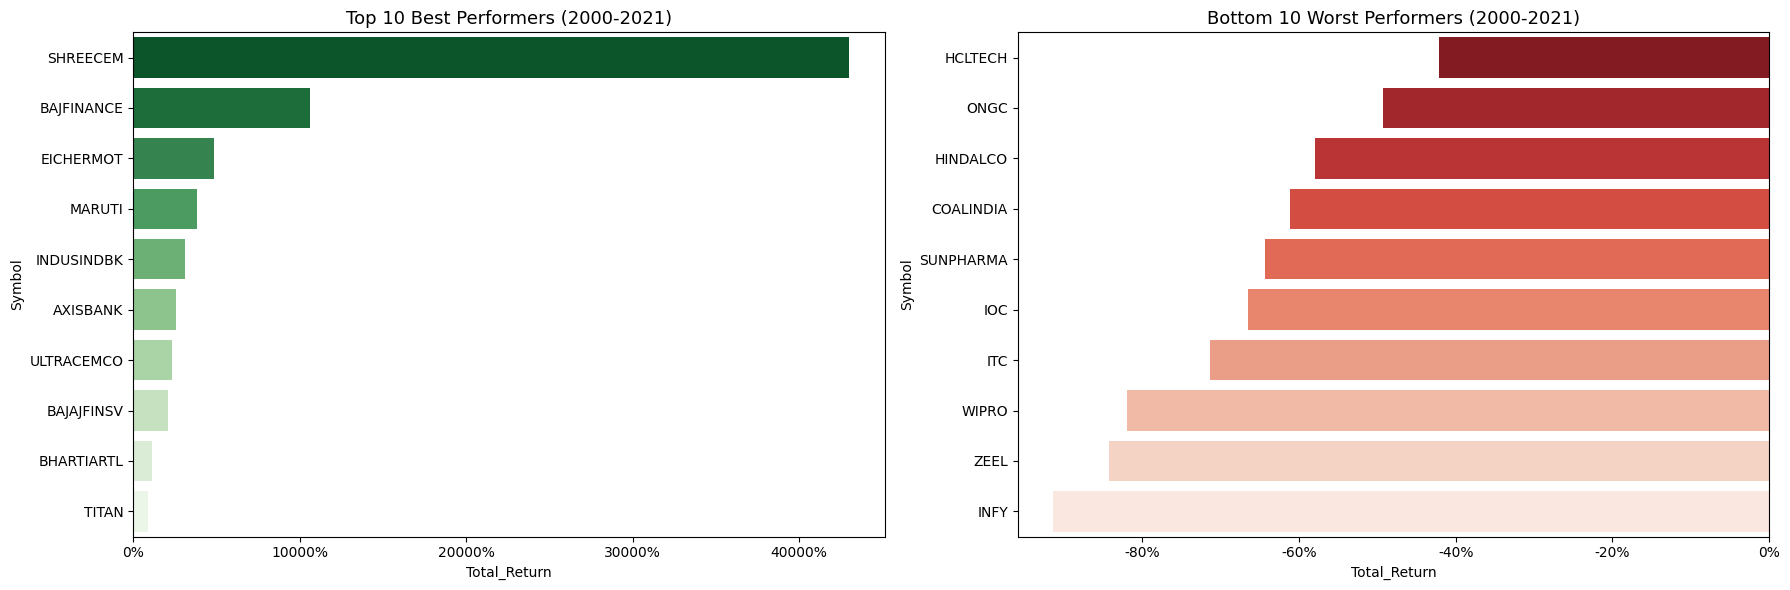

In [16]:
def total_return(group):
    return (group.iloc[-1] / group.iloc[0]) - 1

returns = data.groupby('Symbol')['Close'].apply(total_return).sort_values(ascending=False)
returns = returns.reset_index()
returns.columns = ['Symbol', 'Total_Return']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=returns.head(10), x='Total_Return', y='Symbol',
            palette='Greens_r', ax=axes[0])
axes[0].set_title('Top 10 Best Performers (2000-2021)', fontsize=13)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

sns.barplot(data=returns.tail(10), x='Total_Return', y='Symbol',
            palette='Reds_r', ax=axes[1])
axes[1].set_title('Bottom 10 Worst Performers (2000-2021)', fontsize=13)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

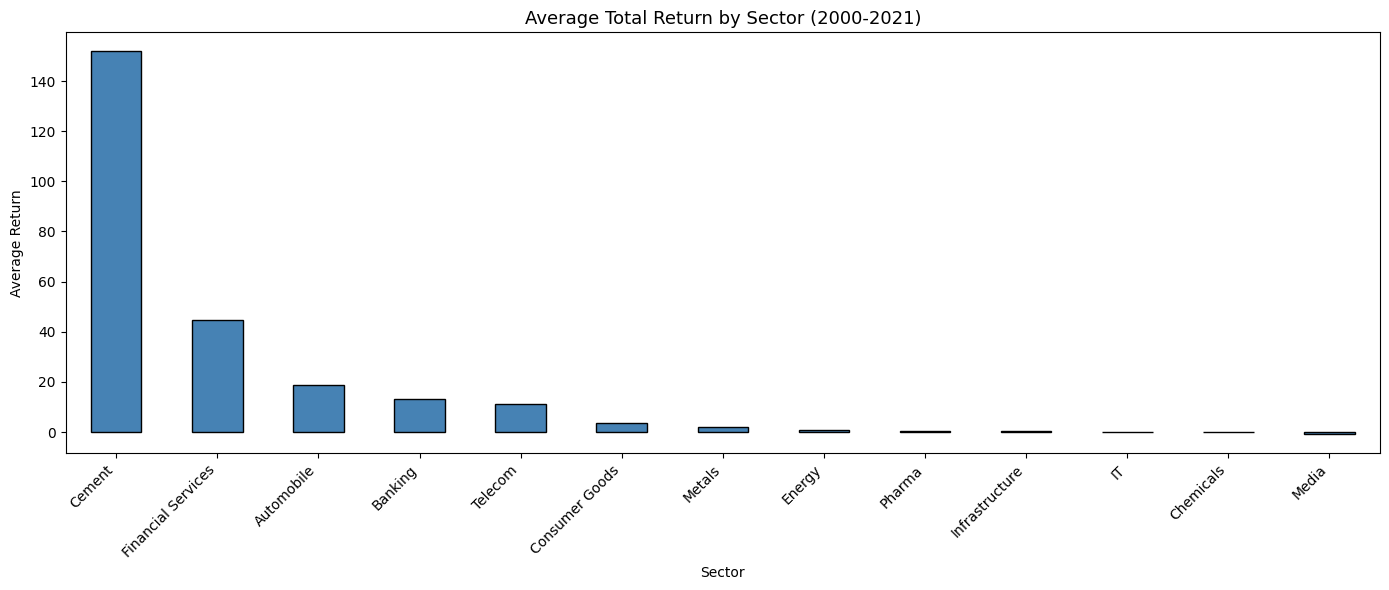

In [17]:
sector_returns = returns.copy()
sector_returns['Sector'] = sector_returns['Symbol'].map(sector_map)
sector_avg = sector_returns.groupby('Sector')['Total_Return'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sector_avg.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Total Return by Sector (2000-2021)', fontsize=13)
plt.ylabel('Average Return')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

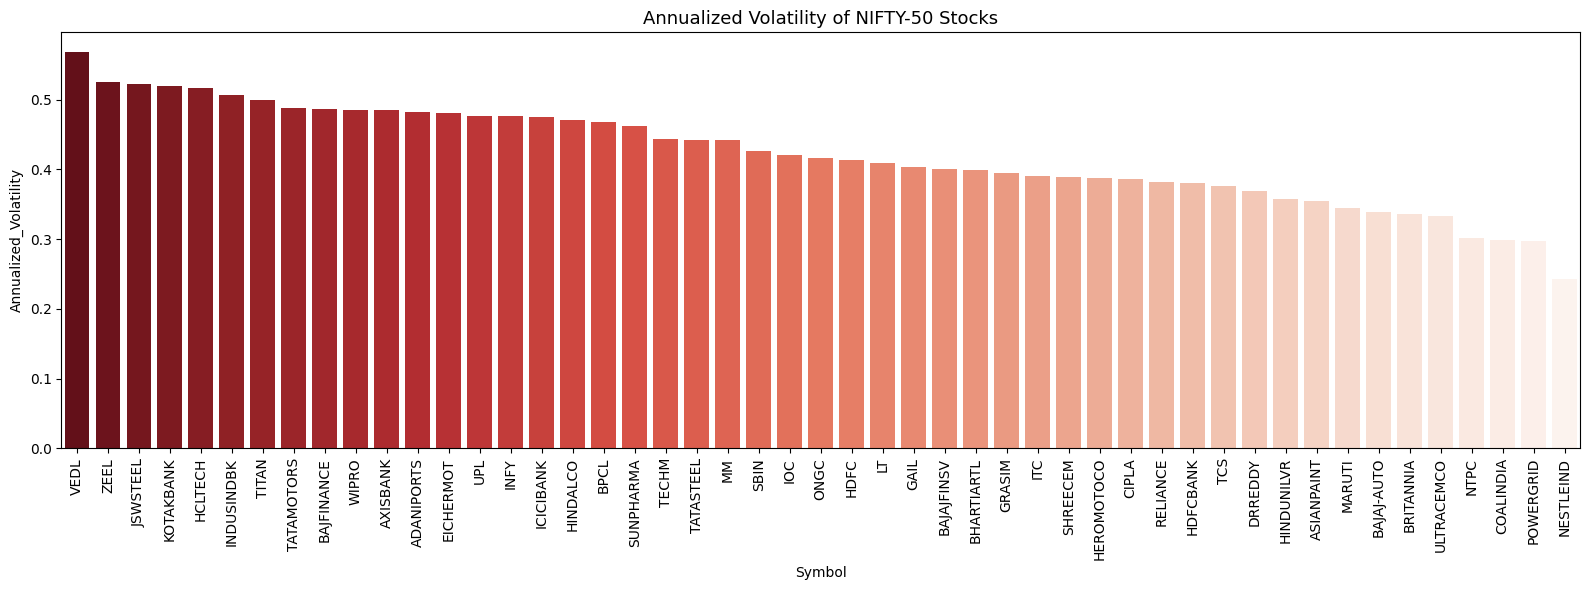

In [18]:
volatility = data.groupby('Symbol')['Daily_Return'].std() * np.sqrt(252)
volatility = volatility.sort_values(ascending=False).reset_index()
volatility.columns = ['Symbol', 'Annualized_Volatility']

plt.figure(figsize=(16, 6))
sns.barplot(data=volatility, x='Symbol', y='Annualized_Volatility', palette='Reds_r')
plt.title('Annualized Volatility of NIFTY-50 Stocks', fontsize=13)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

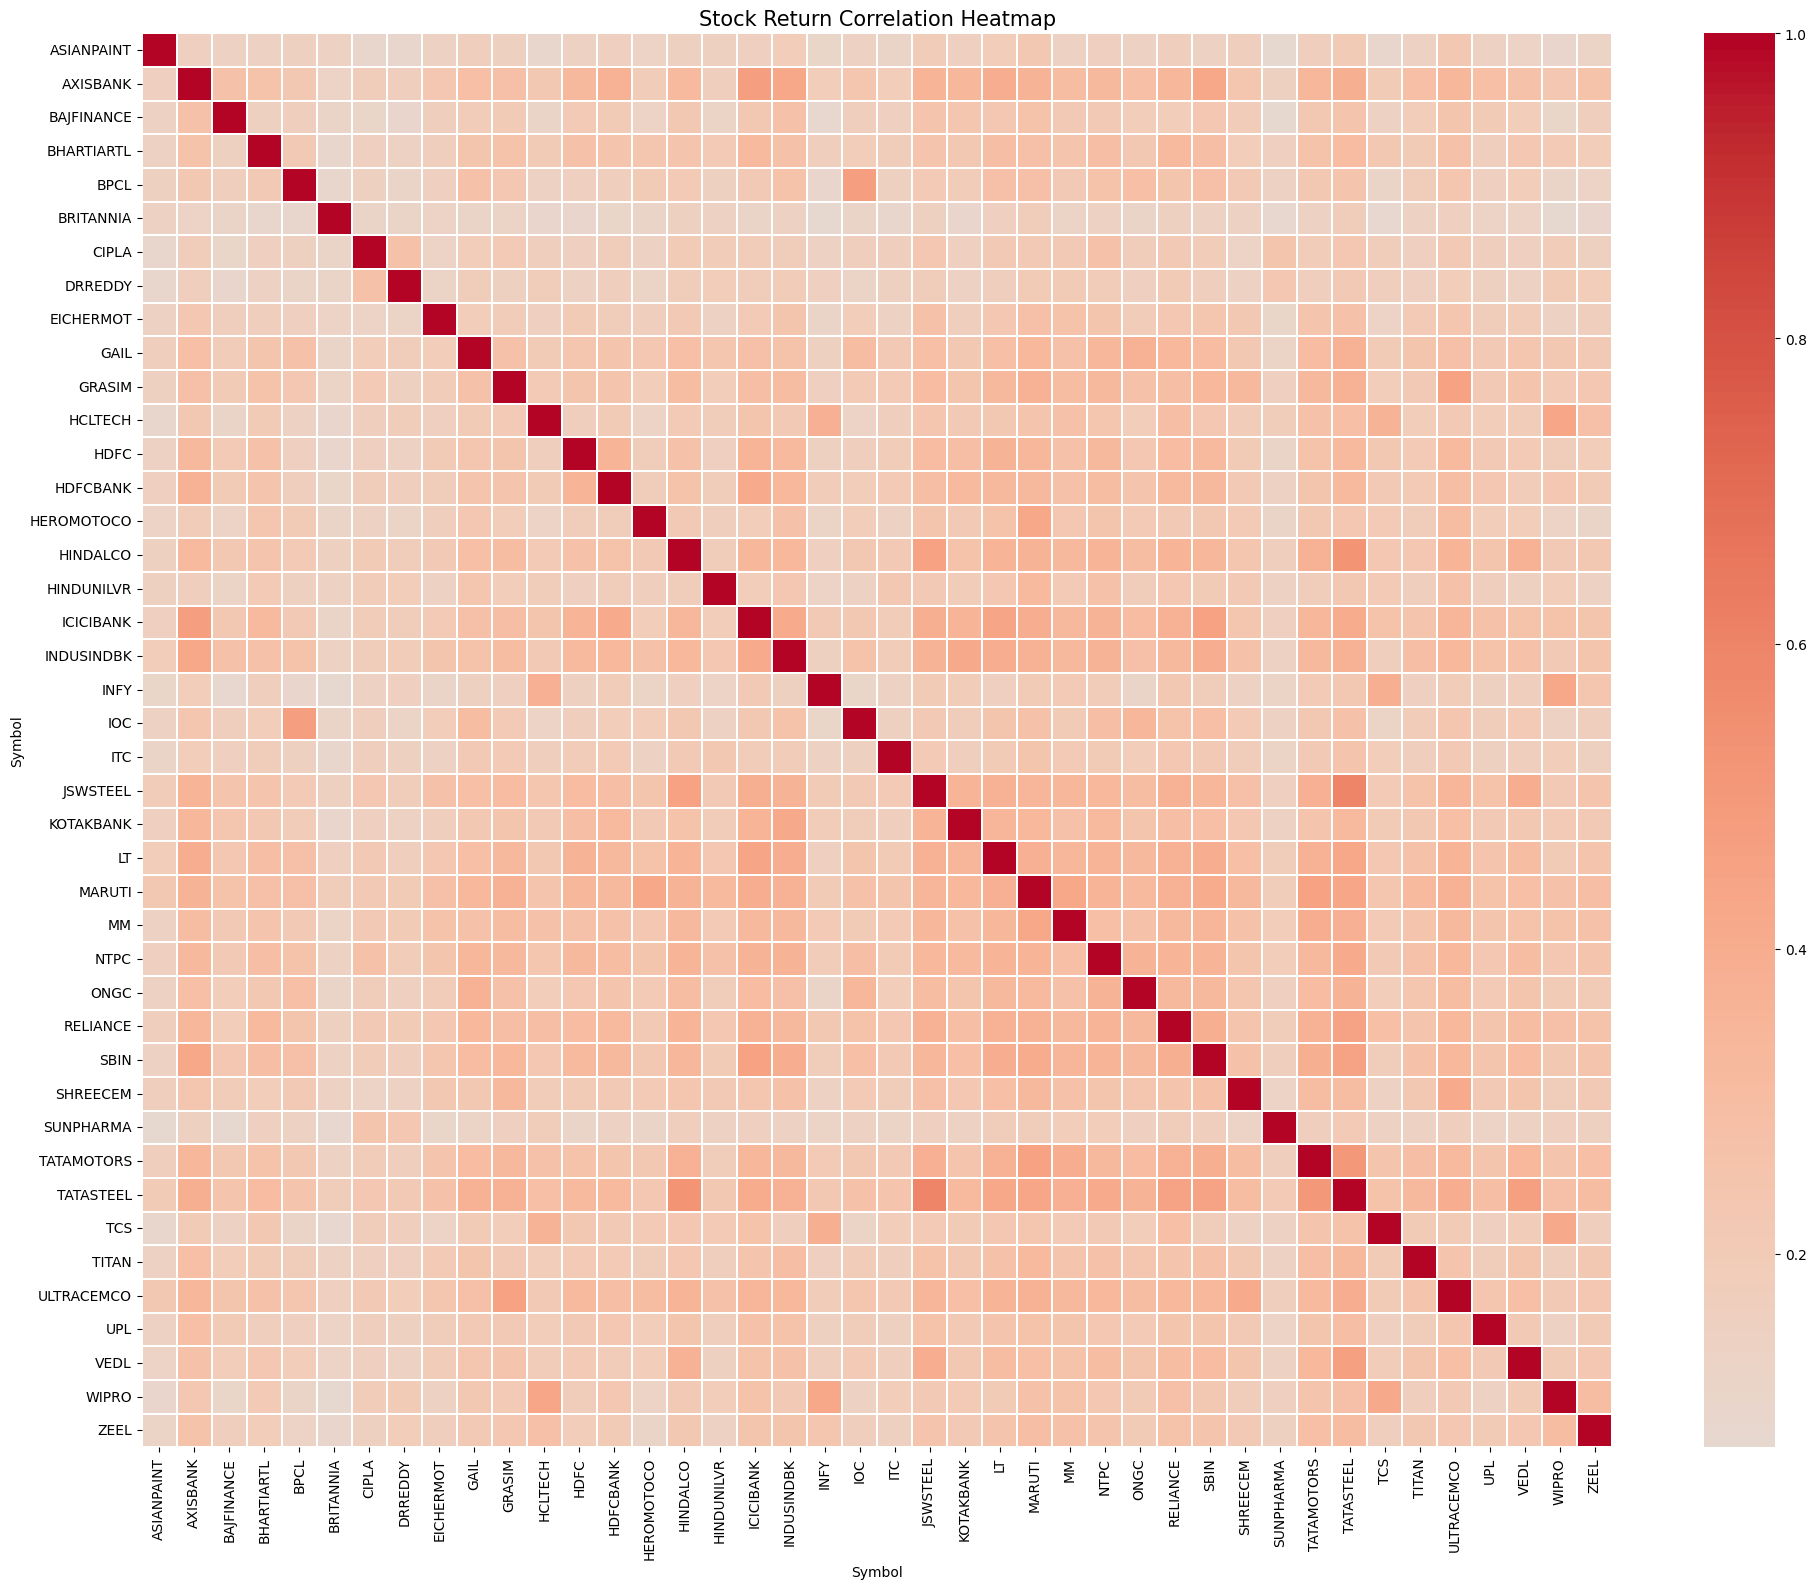

In [19]:
returns_pivot = data.pivot_table(index='Date', columns='Symbol', values='Daily_Return')
returns_pivot = returns_pivot.dropna(thresh=int(0.7 * len(returns_pivot)), axis=1)
corr_matrix = returns_pivot.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False)
plt.title('Stock Return Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.show()

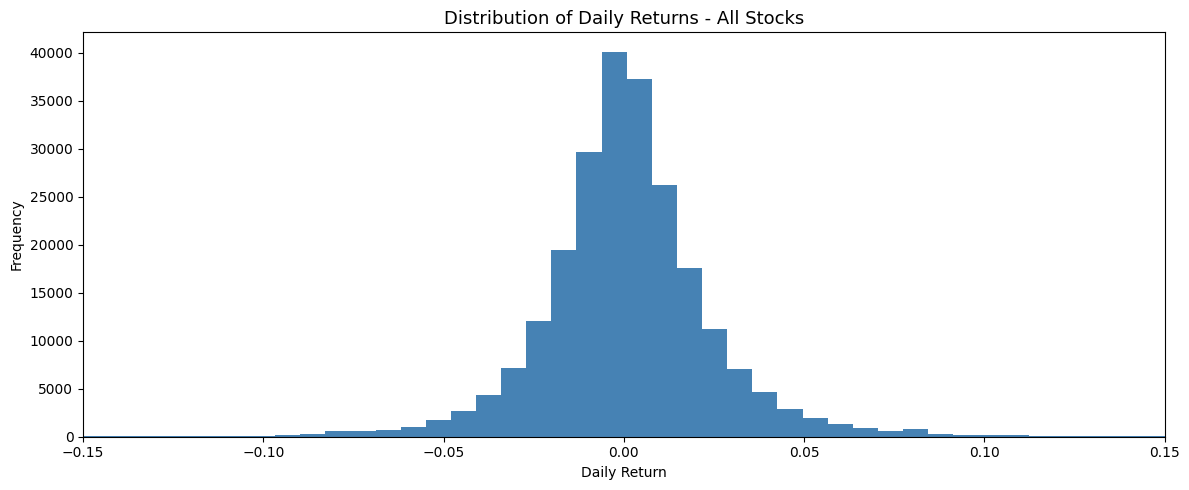

Mean Daily Return : 0.0007
Std Deviation     : 0.0273
Skewness          : -4.4882
Kurtosis          : 132.5812


In [20]:
plt.figure(figsize=(12, 5))
data['Daily_Return'].dropna().plot(kind='hist', bins=200,
                                   color='steelblue', edgecolor='none')
plt.xlim(-0.15, 0.15)
plt.title('Distribution of Daily Returns - All Stocks', fontsize=13)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Mean Daily Return : {data['Daily_Return'].mean():.4f}")
print(f"Std Deviation     : {data['Daily_Return'].std():.4f}")
print(f"Skewness          : {data['Daily_Return'].skew():.4f}")
print(f"Kurtosis          : {data['Daily_Return'].kurt():.4f}")

In [21]:
# Sort data properly
data = data.sort_values(['Symbol', 'Date']).reset_index(drop=True)

# Moving Averages
data['MA20']  = data.groupby('Symbol')['Close'].transform(lambda x: x.rolling(20).mean())
data['MA50']  = data.groupby('Symbol')['Close'].transform(lambda x: x.rolling(50).mean())
data['MA200'] = data.groupby('Symbol')['Close'].transform(lambda x: x.rolling(200).mean())

# Exponential Moving Average
data['EMA20'] = data.groupby('Symbol')['Close'].transform(lambda x: x.ewm(span=20).mean())

print("Moving Averages added ✅")
print(data[['Symbol','Date','Close','MA20','MA50','MA200','EMA20']].dropna().head(5))

Moving Averages added ✅
         Symbol       Date   Close      MA20     MA50      MA200       EMA20
199  ADANIPORTS 2008-09-16  538.35  571.9350  558.811  730.57200  569.249524
200  ADANIPORTS 2008-09-17  493.65  568.1725  559.337  728.22575  562.049569
201  ADANIPORTS 2008-09-18  454.75  561.9025  559.243  726.03000  551.830563
202  ADANIPORTS 2008-09-19  456.40  556.5050  557.344  723.89100  542.741938
203  ADANIPORTS 2008-09-22  443.85  549.9025  554.866  721.50250  533.323658


In [22]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.where(delta > 0, 0)
    loss  = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

data['RSI'] = data.groupby('Symbol')['Close'].transform(compute_rsi)

print("RSI added ✅")
print(data[['Symbol','Date','Close','RSI']].dropna().head(5))

RSI added ✅
        Symbol       Date    Close        RSI
13  ADANIPORTS 2007-12-14  1110.50  65.458735
14  ADANIPORTS 2007-12-17  1044.25  57.481836
15  ADANIPORTS 2007-12-18  1074.95  67.913327
16  ADANIPORTS 2007-12-19  1066.90  68.135795
17  ADANIPORTS 2007-12-20  1060.20  64.654899


In [25]:
def compute_macd(series):
    ema12     = series.ewm(span=12).mean()
    ema26     = series.ewm(span=26).mean()
    macd      = ema12 - ema26
    signal    = macd.ewm(span=9).mean()
    histogram = macd - signal
    return macd, signal, histogram

# Apply per stock
macd_list, signal_list, hist_list = [], [], []

for symbol, group in data.groupby('Symbol'):
    macd, signal, histogram = compute_macd(group['Close'])
    macd_list.append(macd)
    signal_list.append(signal)
    hist_list.append(histogram)

data['MACD']        = pd.concat(macd_list).reindex(data.index)
data['MACD_Signal'] = pd.concat(signal_list).reindex(data.index)
data['MACD_Hist']   = pd.concat(hist_list).reindex(data.index)

print("MACD added ✅")
print(data[['Symbol','Date','Close','MACD','MACD_Signal','MACD_Hist']].dropna().head(5))

MACD added ✅
       Symbol       Date   Close      MACD  MACD_Signal  MACD_Hist
0  ADANIPORTS 2007-11-27  962.90  0.000000     0.000000   0.000000
1  ADANIPORTS 2007-11-28  893.90 -1.548077    -0.860043  -0.688034
2  ADANIPORTS 2007-11-29  884.20 -2.273354    -1.439269  -0.834085
3  ADANIPORTS 2007-11-30  921.55 -1.199002    -1.357877   0.158875
4  ADANIPORTS 2007-12-03  969.30  1.310109    -0.564212   1.874321


In [26]:
# Compute Bollinger Bands directly using transform
data['BB_Middle'] = data.groupby('Symbol')['Close'].transform(lambda x: x.rolling(20).mean())
data['BB_Std']    = data.groupby('Symbol')['Close'].transform(lambda x: x.rolling(20).std())

data['BB_Upper']  = data['BB_Middle'] + (2 * data['BB_Std'])
data['BB_Lower']  = data['BB_Middle'] - (2 * data['BB_Std'])

# Bandwidth
data['BB_Width']  = (data['BB_Upper'] - data['BB_Lower']) / data['BB_Middle']

# Drop helper column
data.drop(columns=['BB_Std'], inplace=True)

print("Bollinger Bands added ✅")
print(data[['Symbol','Date','Close','BB_Upper','BB_Lower','BB_Width']].dropna().head(5))

Bollinger Bands added ✅
        Symbol       Date    Close     BB_Upper    BB_Lower  BB_Width
19  ADANIPORTS 2007-12-26  1199.90  1214.432682  879.842318  0.319529
20  ADANIPORTS 2007-12-27  1211.65  1237.170666  881.979334  0.335221
21  ADANIPORTS 2007-12-28  1249.10  1256.208207  898.461793  0.332066
22  ADANIPORTS 2007-12-31  1268.80  1270.643673  922.486327  0.317498
23  ADANIPORTS 2008-01-01  1296.85  1290.878705  939.781295  0.314792


In [28]:
# Rolling Volatility (21-day)
data['Volatility_21'] = data.groupby('Symbol')['Daily_Return'].transform(
    lambda x: x.rolling(21).std() * np.sqrt(252)
)

# Momentum (current price vs price 20 days ago)
data['Momentum_20'] = data.groupby('Symbol')['Close'].transform(
    lambda x: x.pct_change(20)
)

# Price position within High-Low range
data['Price_Position'] = (data['Close'] - data['Low']) / (data['High'] - data['Low'])

# Volume change
data['Volume_Change'] = data.groupby('Symbol')['Volume'].transform(
    lambda x: x.pct_change()
)

print("Additional features added ✅")
print(data[['Symbol','Date','Momentum_20','Volatility_21',
            'Price_Position','Volume_Change']].dropna().head(5))

Additional features added ✅
        Symbol       Date  Momentum_20  Volatility_21  Price_Position  \
21  ADANIPORTS 2007-12-28     0.397360       0.695950        0.748485   
22  ADANIPORTS 2007-12-31     0.434969       0.623482        0.229412   
23  ADANIPORTS 2008-01-01     0.407249       0.614970        0.599458   
24  ADANIPORTS 2008-01-02     0.348860       0.610126        0.693519   
25  ADANIPORTS 2008-01-03     0.225023       0.613053        0.273576   

    Volume_Change  
21       0.190940  
22      -0.366700  
23      -0.333539  
24       0.432417  
25      -0.282399  


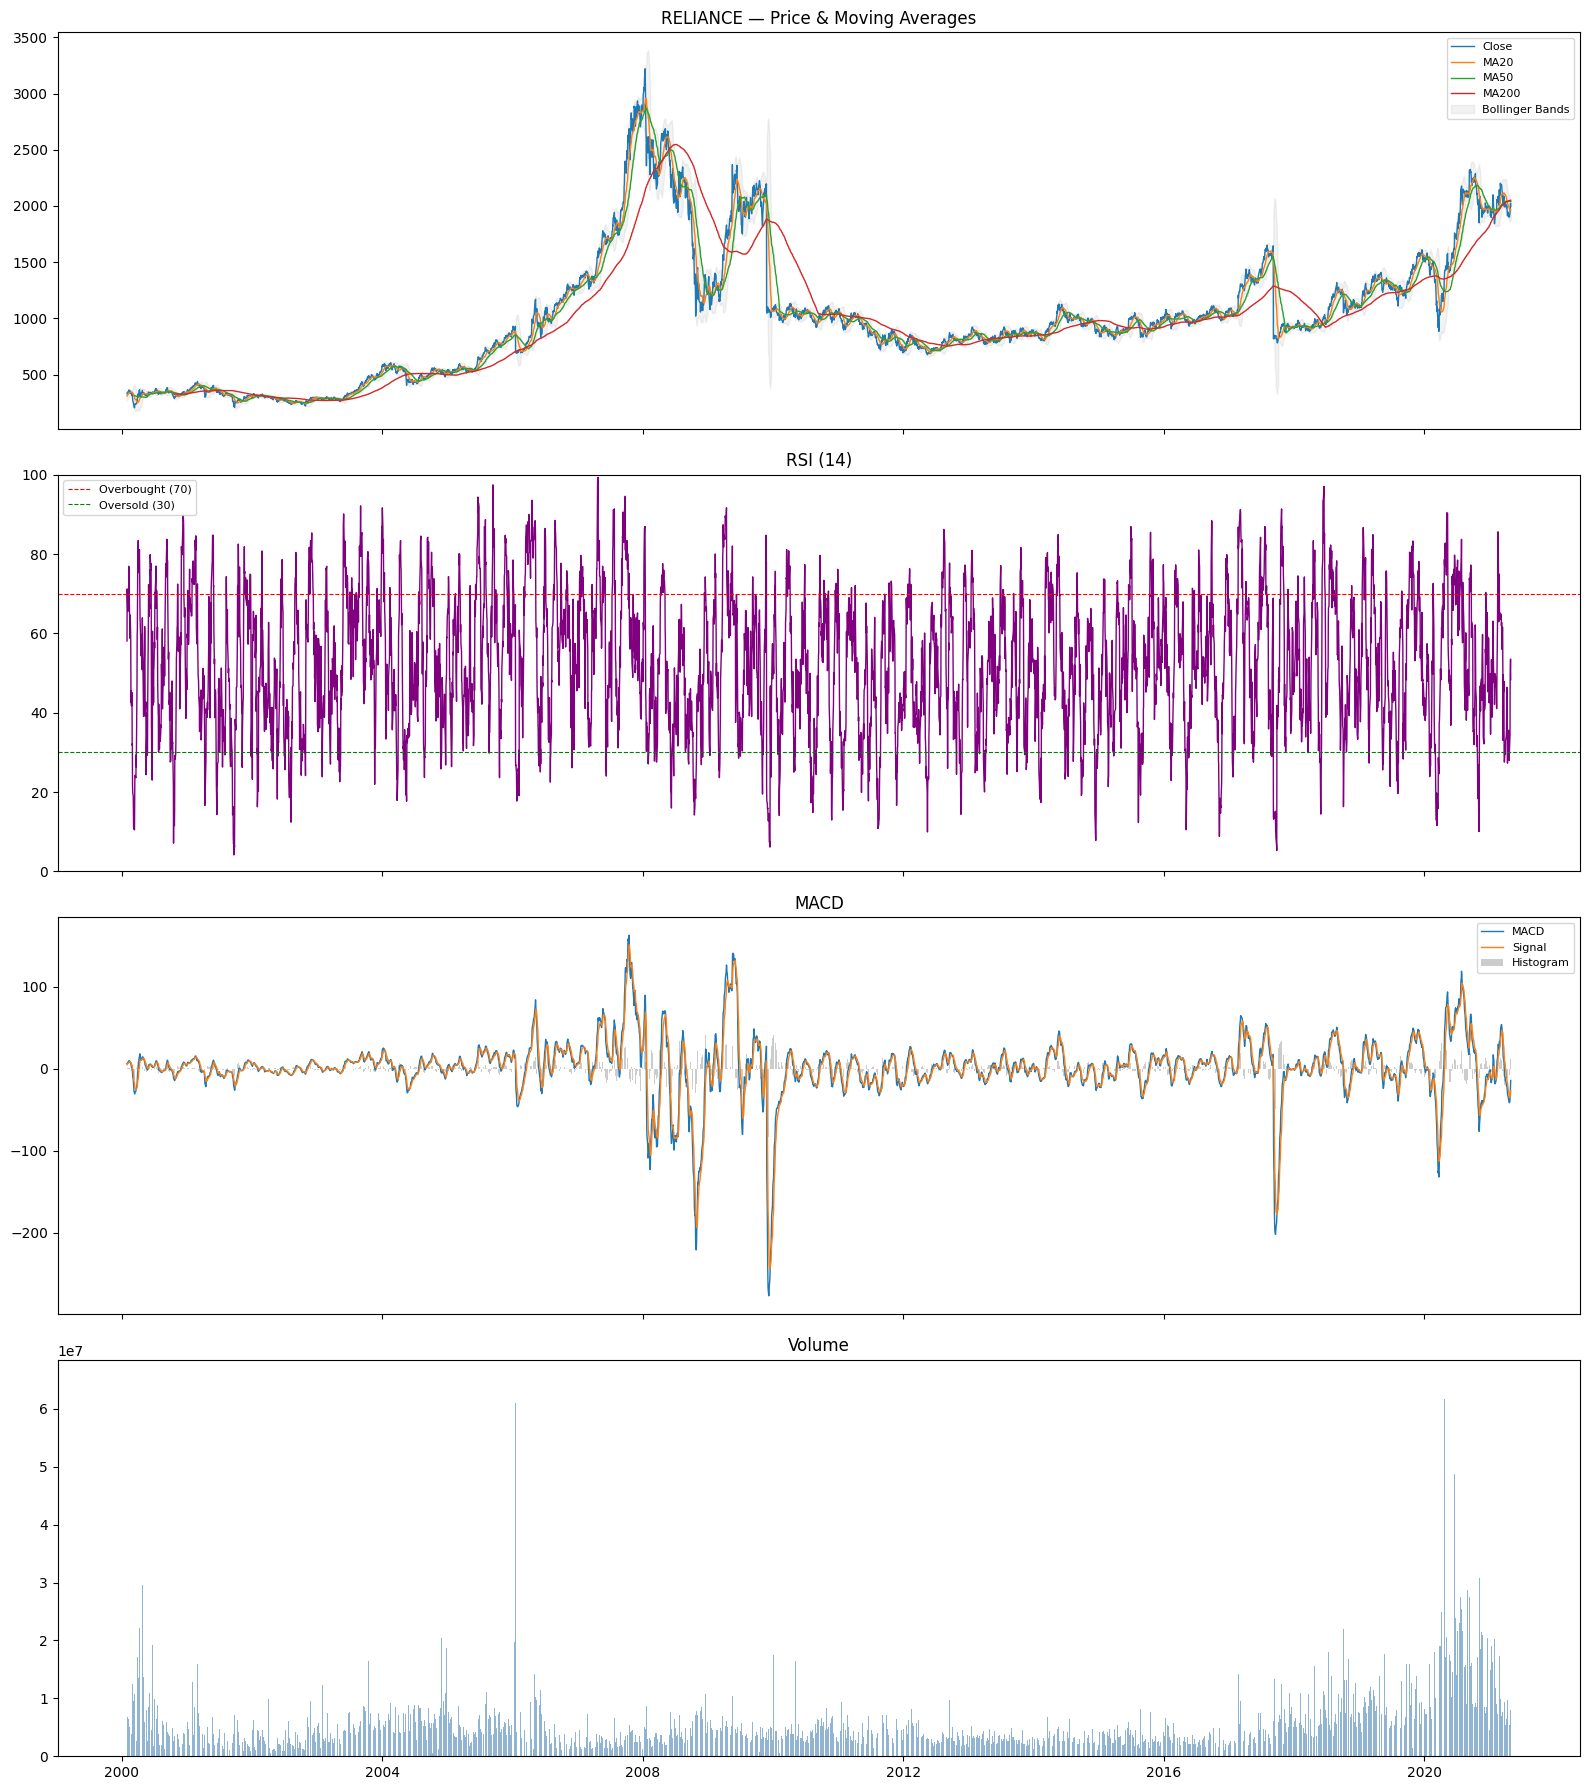

In [29]:
# Pick one stock to visualize — change as you like
stock = 'RELIANCE'
df_stock = data[data['Symbol'] == stock].dropna(subset=['MA20','RSI','MACD']).copy()

fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)

# Price + MAs
axes[0].plot(df_stock['Date'], df_stock['Close'],  label='Close',  linewidth=1)
axes[0].plot(df_stock['Date'], df_stock['MA20'],   label='MA20',   linewidth=1)
axes[0].plot(df_stock['Date'], df_stock['MA50'],   label='MA50',   linewidth=1)
axes[0].plot(df_stock['Date'], df_stock['MA200'],  label='MA200',  linewidth=1)
axes[0].fill_between(df_stock['Date'], df_stock['BB_Upper'],
                     df_stock['BB_Lower'], alpha=0.1, color='gray', label='Bollinger Bands')
axes[0].set_title(f'{stock} — Price & Moving Averages', fontsize=12)
axes[0].legend(fontsize=8)

# RSI
axes[1].plot(df_stock['Date'], df_stock['RSI'], color='purple', linewidth=1)
axes[1].axhline(70, color='red',   linestyle='--', linewidth=0.8, label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
axes[1].set_title('RSI (14)', fontsize=12)
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 100)

# MACD
axes[2].plot(df_stock['Date'], df_stock['MACD'],        label='MACD',   linewidth=1)
axes[2].plot(df_stock['Date'], df_stock['MACD_Signal'], label='Signal', linewidth=1)
axes[2].bar(df_stock['Date'],  df_stock['MACD_Hist'],
            label='Histogram', color='gray', alpha=0.4, width=1)
axes[2].set_title('MACD', fontsize=12)
axes[2].legend(fontsize=8)

# Volume
axes[3].bar(df_stock['Date'], df_stock['Volume'], color='steelblue', alpha=0.6, width=1)
axes[3].set_title('Volume', fontsize=12)

plt.tight_layout()
plt.show()

In [30]:
data.to_csv('/content/data/processed_data.csv', index=False)
print(f"Processed data saved ✅")
print(f"Shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")

Processed data saved ✅
Shape: (235192, 33)
Columns: ['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble', 'Sector', 'Daily_Return', 'MA20', 'MA50', 'MA200', 'EMA20', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'Volatility_21', 'Momentum_20', 'Price_Position', 'Volume_Change']
